# Optimal Orbit Selection for Space Debris Removal

This notebook demonstrates the Python implementation of optimal orbit selection algorithms for space debris removal missions. We implement three methods:

1. **Brute Force Permutation** - Exhaustive search for small problem sizes
2. **Series Method** - A greedy algorithm that selects the best next orbit at each step
3. **Genetic Algorithm (GA)** - A metaheuristic optimization approach

The objective is to find the optimal order of orbit visits that minimizes the total spent propellant mass.

## Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations
import os
import sys

# Add current directory to path for imports
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

# Import custom modules
from tle_parser import tle_to_orbital_params
from orbital_mechanics import plane_change
from population import popu_initialize
from fitness import fitness_evaluate
from repair import repair
from selection import root_parent_select
from crossover import crossover
from mutation import mutation, inverse_mutation
from next_generation import next_popu
from objective import obj_min_spent_prop_mass

# Enable inline plotting
%matplotlib inline

print("All modules loaded successfully!")

All modules loaded successfully!


## Common Parameters

These are the spacecraft and mission parameters used across all methods.

In [2]:
# Spacecraft parameters
dry_mass_0 = 795      # Initial dry mass in kg
prop_mass_0 = 2700    # Propellant mass in kg
isp = 300             # Specific impulse in seconds
g_0 = 9.81            # Gravitational acceleration at Earth's surface in m/s^2

# Space debris mass options:
# - 0 for no SD
# - 50 for Payload Module (PM)
# - 1500 for Rocket Body (RB)
sd_mass = 1500        # Space debris mass in kg

print(f"Spacecraft Parameters:")
print(f"  Dry Mass: {dry_mass_0} kg")
print(f"  Propellant Mass: {prop_mass_0} kg")
print(f"  Specific Impulse: {isp} s")
print(f"  Space Debris Mass: {sd_mass} kg")

Spacecraft Parameters:
  Dry Mass: 795 kg
  Propellant Mass: 2700 kg
  Specific Impulse: 300 s
  Space Debris Mass: 1500 kg


## Load Orbital Data

Load the Two-Line Element (2LE) data for the target space debris objects.

In [3]:
# Load orbital parameters from TLE file
tle_file = os.path.join('..', 'Targeted_SDs_2LE.txt')
orbparam = tle_to_orbital_params(tle_file)

print(f"Loaded {len(orbparam)} orbital objects")
print(f"\nOrbital parameters columns: [a (km), e, inc (deg), RAAN (deg), arg_perigee (deg), mean_anomaly (deg)]")
print(f"\nFirst 5 objects:")
print(f"{'Object':<8} {'a (km)':<12} {'e':<10} {'inc (deg)':<12}")
print("-" * 42)
for i in range(min(5, len(orbparam))):
    print(f"{i+1:<8} {orbparam[i, 0]:<12.2f} {orbparam[i, 1]:<10.6f} {orbparam[i, 2]:<12.4f}")

Loaded 21 orbital objects

Orbital parameters columns: [a (km), e, inc (deg), RAAN (deg), arg_perigee (deg), mean_anomaly (deg)]

First 5 objects:
Object   a (km)       e          inc (deg)   
------------------------------------------
1        6723.22      0.001564   82.5521     
2        7047.06      0.032561   82.3790     
3        6880.70      0.010770   82.5483     
4        6991.36      0.026401   82.1853     
5        6987.29      0.026183   81.9545     


---
# Method 1: Brute Force Permutation

For a small number of orbits (5 in this case), we can exhaustively evaluate all possible permutations to find the globally optimal solution. This serves as a benchmark for other methods.

**Note:** With 5 orbits and a fixed starting orbit, there are 4! = 24 permutations to evaluate.

In [4]:
def run_brute_force(orbits, dry_mass_0, prop_mass_0, sd_mass, isp, g_0):
    """Run brute force permutation to find optimal orbit order."""
    n = orbits.shape[0]
    
    # Determine the starting orbit (minimum semi-major axis)
    min_a_index = np.argmin(orbits[:, 1])
    if np.all(orbits[:, 1] == orbits[min_a_index, 1]):
        start_index = np.argmin(orbits[:, 0])
    else:
        start_index = min_a_index
    
    # Generate all permutations
    to_visit = [i for i in range(n) if i != start_index]
    all_permutations = list(permutations(to_visit))
    num_perms = len(all_permutations)
    
    print(f"Evaluating {num_perms} permutations...")
    
    # Track results
    total_mass_change = np.zeros((num_perms, n))
    prop_mass_change = np.zeros((num_perms, n))
    stp_mass = np.zeros((num_perms, n))
    optimal_perm = None
    min_stp = np.inf
    final_index = 0
    
    for i, perm in enumerate(all_permutations):
        test_perm = [start_index] + list(perm)
        spent_prop_mass_total = 0
        dry_mass = dry_mass_0
        prop_mass = prop_mass_0
        
        # Initial values
        total_mass_change[i, 0] = dry_mass_0 + sd_mass + prop_mass_0
        prop_mass_change[i, 0] = prop_mass_0
        
        for j in range(1, n):
            orbit1, orbit2 = test_perm[j - 1], test_perm[j]
            inc1, inc2 = orbits[orbit1, 0], orbits[orbit2, 0]
            a1, a2 = orbits[orbit1, 1], orbits[orbit2, 1]
            
            dry_mass += sd_mass
            delta_v = plane_change(inc1, inc2, a1, a2)
            spent_prop_mass = (dry_mass + prop_mass) * (1 - np.exp(-delta_v / (isp * g_0)))
            spent_prop_mass_total += spent_prop_mass
            prop_mass -= spent_prop_mass
            
            stp_mass[i, j] = spent_prop_mass_total
            total_mass_change[i, j] = dry_mass + prop_mass
            prop_mass_change[i, j] = prop_mass
        
        if spent_prop_mass_total < min_stp:
            min_stp = spent_prop_mass_total
            optimal_perm = [x + 1 for x in test_perm]  # 1-indexed
            final_index = i
    
    return optimal_perm, min_stp, prop_mass_change[final_index, :], total_mass_change[final_index, :]

In [5]:
# Run brute force on first 5 orbits
orbits_bf = orbparam[:5, [2, 0]]  # [inclination, semi-major axis]
n_bf = orbits_bf.shape[0]

# Use sd_mass = 0 for brute force (as in MATLAB)
bf_optimal, bf_min_stp, bf_prop_mass, bf_total_mass = run_brute_force(
    orbits_bf, dry_mass_0, prop_mass_0, 0, isp, g_0
)

print(f"\n{'='*60}")
print(f"BRUTE FORCE RESULTS (5 orbits, SD Mass = 0 kg)")
print(f"{'='*60}")
print(f"\nOptimal Order: {bf_optimal}")
print(f"Minimum Spent Propellant Mass: {bf_min_stp:.2f} kg")
print(f"\nPropellant Mass at each step: {np.round(bf_prop_mass, 2)}")
print(f"Total Mass at each step: {np.round(bf_total_mass, 2)}")

Evaluating 24 permutations...

BRUTE FORCE RESULTS (5 orbits, SD Mass = 0 kg)

Optimal Order: [np.int64(1), 3, 2, 4, 5]
Minimum Spent Propellant Mass: 286.27 kg

Propellant Mass at each step: [2700.   2596.32 2490.72 2447.16 2413.73]
Total Mass at each step: [3495.   3391.32 3285.72 3242.16 3208.73]


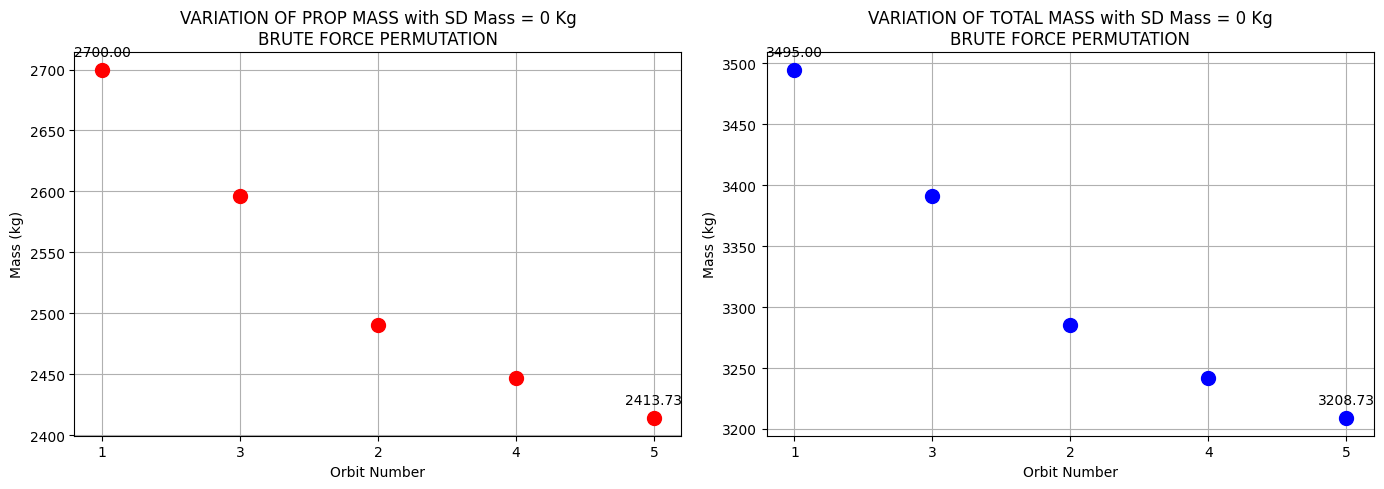

In [6]:
# Plot brute force results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Propellant mass plot
axes[0].plot(range(1, n_bf + 1), bf_prop_mass, 'or', markersize=10)
axes[0].set_xticks(range(1, n_bf + 1))
axes[0].set_xticklabels(bf_optimal)
axes[0].set_xlabel('Orbit Number')
axes[0].set_ylabel('Mass (kg)')
axes[0].set_title('VARIATION OF PROP MASS with SD Mass = 0 Kg\nBRUTE FORCE PERMUTATION')
axes[0].grid(True)
for i in [0, n_bf - 1]:
    axes[0].annotate(f'{bf_prop_mass[i]:.2f}', (i + 1, bf_prop_mass[i]), 
                    textcoords="offset points", xytext=(0, 10), ha='center')

# Total mass plot
axes[1].plot(range(1, n_bf + 1), bf_total_mass, 'ob', markersize=10)
axes[1].set_xticks(range(1, n_bf + 1))
axes[1].set_xticklabels(bf_optimal)
axes[1].set_xlabel('Orbit Number')
axes[1].set_ylabel('Mass (kg)')
axes[1].set_title('VARIATION OF TOTAL MASS with SD Mass = 0 Kg\nBRUTE FORCE PERMUTATION')
axes[1].grid(True)
for i in [0, n_bf - 1]:
    axes[1].annotate(f'{bf_total_mass[i]:.2f}', (i + 1, bf_total_mass[i]), 
                    textcoords="offset points", xytext=(0, 10), ha='center')

plt.tight_layout()
plt.show()

---
# Method 2: Series (Greedy) Method

The series method uses a greedy approach: at each step, it selects the next orbit that requires the minimum propellant expenditure. This method is fast but may not find the globally optimal solution.

In [7]:
def run_series_method(orbits, dry_mass_init, prop_mass_init, sd_mass, isp, g_0):
    """Run the series (greedy) method for optimal orbit selection."""
    n = orbits.shape[0]
    a = orbits[:, 1]  # Semi-major axes
    inclinations = orbits[:, 0]  # Inclinations
    sd_number = np.arange(1, n + 1)  # 1-indexed orbit numbers
    
    # Sort by semi-major axis
    sorted_indices = np.argsort(a)
    a_sorted = a[sorted_indices]
    inclinations_sorted = inclinations[sorted_indices]
    sd_number_sorted = sd_number[sorted_indices]
    
    # Start from lowest semi-major axis
    current_orbit = 0
    visited = np.zeros(n, dtype=bool)
    visited[current_orbit] = True
    sequence = [sd_number_sorted[current_orbit]]
    total_delta_v = 0
    
    # Initialize mass tracking
    dry_mass = dry_mass_init
    propmass = prop_mass_init
    prop_mass_change = np.zeros(n)
    total_mass_change = np.zeros(n)
    prop_mass_change[0] = propmass
    total_mass_change[0] = dry_mass + propmass
    
    for i in range(n - 1):
        spent_prop_mass_o = np.inf
        delta_v_opti = np.inf
        selected_orbit = -1
        
        for j in range(n):
            if not visited[j]:
                delta_v = plane_change(inclinations_sorted[current_orbit], inclinations_sorted[j],
                                       a_sorted[current_orbit], a_sorted[j])
                dry_mass_with_sd = dry_mass + sd_mass
                spent_prop_mass = (dry_mass_with_sd + propmass) * (1 - np.exp(-delta_v / (isp * g_0)))
                
                if spent_prop_mass <= propmass and spent_prop_mass < spent_prop_mass_o:
                    spent_prop_mass_o = spent_prop_mass
                    delta_v_opti = delta_v
                    selected_orbit = j
        
        if selected_orbit != -1:
            sequence.append(sd_number_sorted[selected_orbit])
            total_delta_v += delta_v_opti
            propmass -= spent_prop_mass_o
            dry_mass += sd_mass
            prop_mass_change[i + 1] = propmass
            total_mass_change[i + 1] = dry_mass + propmass
            current_orbit = selected_orbit
            visited[current_orbit] = True
        else:
            print(f"No valid next orbit found at step {i + 1}. Stopping.")
            break
    
    return sequence, total_delta_v, prop_mass_change[:len(sequence)], total_mass_change[:len(sequence)]

In [8]:
# Run series method on 21 orbits with SD mass = 1500 kg
orbits_series = orbparam[:21, [2, 0]]  # [inclination, semi-major axis]
sd_mass_series = 1500

series_seq, series_dv, series_prop, series_total = run_series_method(
    orbits_series, dry_mass_0, prop_mass_0, sd_mass_series, isp, g_0
)

print(f"\n{'='*60}")
print(f"SERIES METHOD RESULTS (21 orbits, SD Mass = {sd_mass_series} kg)")
print(f"{'='*60}")
print(f"\nOptimal Sequence: {series_seq}")
print(f"Orbits Visited: {len(series_seq)} out of 21")
print(f"Total Delta-V: {series_dv:.2f} m/s")
print(f"\nFinal Propellant Mass: {series_prop[-1]:.2f} kg")
print(f"Final Total Mass: {series_total[-1]:.2f} kg")

No valid next orbit found at step 19. Stopping.

SERIES METHOD RESULTS (21 orbits, SD Mass = 1500 kg)

Optimal Sequence: [np.int64(8), np.int64(1), np.int64(15), np.int64(17), np.int64(19), np.int64(20), np.int64(14), np.int64(16), np.int64(10), np.int64(18), np.int64(6), np.int64(7), np.int64(13), np.int64(9), np.int64(3), np.int64(21), np.int64(4), np.int64(5), np.int64(2)]
Orbits Visited: 19 out of 21
Total Delta-V: 326.20 m/s

Final Propellant Mass: 307.42 kg
Final Total Mass: 28102.42 kg


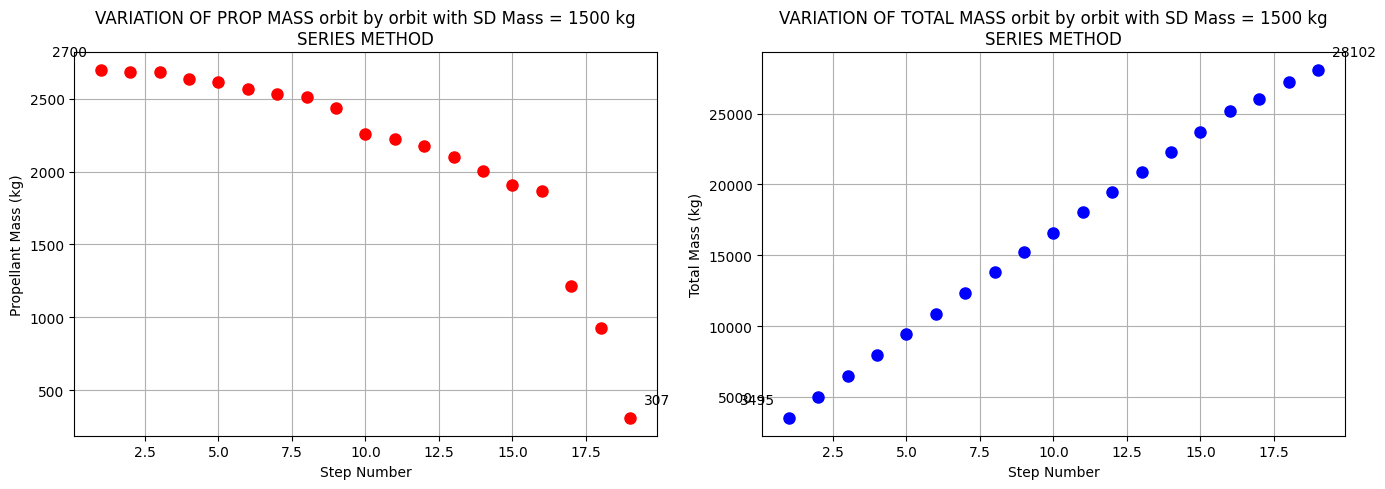

In [9]:
# Plot series method results
n_visited = len(series_seq)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Propellant mass plot
axes[0].plot(range(1, n_visited + 1), series_prop, 'or', markersize=8)
axes[0].set_xlabel('Step Number')
axes[0].set_ylabel('Propellant Mass (kg)')
axes[0].set_title(f'VARIATION OF PROP MASS orbit by orbit with SD Mass = {sd_mass_series} kg\nSERIES METHOD')
axes[0].grid(True)
if n_visited > 0:
    axes[0].annotate(f'{series_prop[0]:.0f}', (1, series_prop[0]), 
                    textcoords="offset points", xytext=(-10, 10), ha='right')
    axes[0].annotate(f'{series_prop[-1]:.0f}', (n_visited, series_prop[-1]), 
                    textcoords="offset points", xytext=(10, 10), ha='left')

# Total mass plot
axes[1].plot(range(1, n_visited + 1), series_total, 'ob', markersize=8)
axes[1].set_xlabel('Step Number')
axes[1].set_ylabel('Total Mass (kg)')
axes[1].set_title(f'VARIATION OF TOTAL MASS orbit by orbit with SD Mass = {sd_mass_series} kg\nSERIES METHOD')
axes[1].grid(True)
if n_visited > 0:
    axes[1].annotate(f'{series_total[0]:.0f}', (1, series_total[0]), 
                    textcoords="offset points", xytext=(-10, 10), ha='right')
    axes[1].annotate(f'{series_total[-1]:.0f}', (n_visited, series_total[-1]), 
                    textcoords="offset points", xytext=(10, 10), ha='left')

plt.tight_layout()
plt.show()

---
# Method 3: Genetic Algorithm (GA)

The Genetic Algorithm is a metaheuristic optimization method inspired by natural evolution. It maintains a population of candidate solutions and uses selection, crossover, and mutation to evolve better solutions over generations.

**Key Features:**
- Adaptive mutation switching between swap and inverse mutation based on stagnation
- Root-based parent selection (1/√rank)
- Ordered crossover to maintain valid permutations
- Repair function for infeasible solutions

**Note:** For this demo, we use reduced parameters (population=50, generations=25) for faster execution. For production use, increase to population=500, generations=250.

In [10]:
def run_ga(orbits, dry_mass_0, prop_mass_0, sd_mass, isp, g_0, 
           popu_size=50, max_generations=25, mutate_rate=0.9, crossover_rate=0.9,
           verbose=True):
    """Run the genetic algorithm for optimal orbit selection."""
    n = orbits.shape[0]
    
    # Find starting orbit (minimum semi-major axis)
    min_a_ind = np.argmin(orbits[:, 1]) + 1  # 1-indexed
    
    # Initialize tracking arrays
    mean_fitness = np.zeros(max_generations)
    best_fitness = np.zeros(max_generations)
    diversity_history = np.zeros(max_generations)
    
    # Initialize population
    population = popu_initialize(popu_size, n, min_a_ind, orbits, dry_mass_0, prop_mass_0, isp, g_0, sd_mass)
    
    # Stagnation detection parameters
    stall_count = 0
    switch_mutation = True
    threshold_std = 0.1
    no_switch_zone = 10
    switch_after = 5
    best_fitness_array = np.full(no_switch_zone // 2, np.inf)
    
    # Main GA loop
    for generation in range(max_generations):
        # Evaluate Fitness
        fitness = fitness_evaluate(population, orbits, dry_mass_0, prop_mass_0, isp, g_0, sd_mass)
        
        # Repair invalid solutions
        for i in range(popu_size):
            if np.isinf(fitness[i]):
                population[i, :] = repair(population[i, :], orbits, dry_mass_0, prop_mass_0, isp, g_0, sd_mass)
                fitness[i] = fitness_evaluate(population[i:i+1, :], orbits, dry_mass_0, prop_mass_0, isp, g_0, sd_mass)[0]
        
        mean_fitness[generation] = np.mean(fitness)
        best_fitness[generation] = np.min(fitness)
        
        # Stagnation detection
        if generation >= no_switch_zone:
            best_fitness_array = np.roll(best_fitness_array, -1)
            best_fitness_array[-1] = best_fitness[generation]
            if np.std(best_fitness_array) < threshold_std:
                stall_count += 1
            else:
                stall_count = 0
        else:
            best_fitness_array[generation % len(best_fitness_array)] = best_fitness[generation]
        
        # Switch mutation method if stalled
        if stall_count >= switch_after:
            switch_mutation = not switch_mutation
            stall_count = 0
        
        # Diversity calculation
        pairwise_distances = np.zeros((popu_size, popu_size))
        for i in range(popu_size):
            for j in range(i + 1, popu_size):
                hamming_dist = np.sum(population[i, :] != population[j, :])
                pairwise_distances[i, j] = hamming_dist
                pairwise_distances[j, i] = hamming_dist
        diversity_history[generation] = np.mean(pairwise_distances)
        
        # Selection, Crossover, Mutation
        selected_parents = root_parent_select(population, fitness, popu_size)
        child = crossover(selected_parents, popu_size, crossover_rate, min_a_ind)
        if switch_mutation:
            child = mutation(child, mutate_rate, min_a_ind)
        else:
            child = inverse_mutation(child, mutate_rate, min_a_ind)
        
        # Create new population
        population = next_popu(population, child, fitness)
        
        if verbose and (generation + 1) % 5 == 0:
            print(f'Generation {generation + 1}: Best = {best_fitness[generation]:.2f}, Mean = {mean_fitness[generation]:.2f}')
    
    # Final results
    fitness = fitness_evaluate(population, orbits, dry_mass_0, prop_mass_0, isp, g_0, sd_mass)
    best_ind = np.argmin(fitness)
    final_order = population[best_ind, :]
    
    result = obj_min_spent_prop_mass(final_order, orbits, dry_mass_0, prop_mass_0, isp, g_0, sd_mass, store=True)
    spent_prop_mass_total, total_mass_change, prop_mass_change, _, _, _ = result
    
    return final_order, spent_prop_mass_total, prop_mass_change, total_mass_change, \
           mean_fitness, best_fitness, diversity_history

In [11]:
# Run GA on 10 orbits (reduced for faster demo)
orbits_ga = orbparam[:10, [2, 0]]  # [inclination, semi-major axis]
n_ga = orbits_ga.shape[0]
sd_mass_ga = 1500

# Reduced parameters for notebook demo
ga_popu_size = 50
ga_max_gen = 25

print(f"Running GA with:")
print(f"  Orbits: {n_ga}")
print(f"  Population: {ga_popu_size}")
print(f"  Generations: {ga_max_gen}")
print(f"  SD Mass: {sd_mass_ga} kg")
print("\nProgress:")

ga_order, ga_stp, ga_prop, ga_total, ga_mean, ga_best, ga_diversity = run_ga(
    orbits_ga, dry_mass_0, prop_mass_0, sd_mass_ga, isp, g_0,
    popu_size=ga_popu_size, max_generations=ga_max_gen
)

print(f"\n{'='*60}")
print(f"GENETIC ALGORITHM RESULTS ({n_ga} orbits, SD Mass = {sd_mass_ga} kg)")
print(f"{'='*60}")
print(f"\nOptimal Order: {ga_order}")
print(f"Total Spent Propellant Mass: {ga_stp:.2f} kg")
print(f"\nFinal Propellant Mass: {ga_prop[-1]:.2f} kg")
print(f"Final Total Mass: {ga_total[-1]:.2f} kg")

Running GA with:
  Orbits: 10
  Population: 50
  Generations: 25
  SD Mass: 1500 kg

Progress:
Generation 5: Best = 1585.86, Mean = 2079.16
Generation 10: Best = 1420.44, Mean = 1828.13
Generation 15: Best = 1308.89, Mean = 1726.84


Generation 20: Best = 1298.81, Mean = 1682.99
Generation 25: Best = 1242.24, Mean = 1627.96

GENETIC ALGORITHM RESULTS (10 orbits, SD Mass = 1500 kg)

Optimal Order: [ 8  1 10  5  4  2  3  9  7  6]
Total Spent Propellant Mass: 1242.24 kg

Final Propellant Mass: 1457.76 kg
Final Total Mass: 15752.76 kg


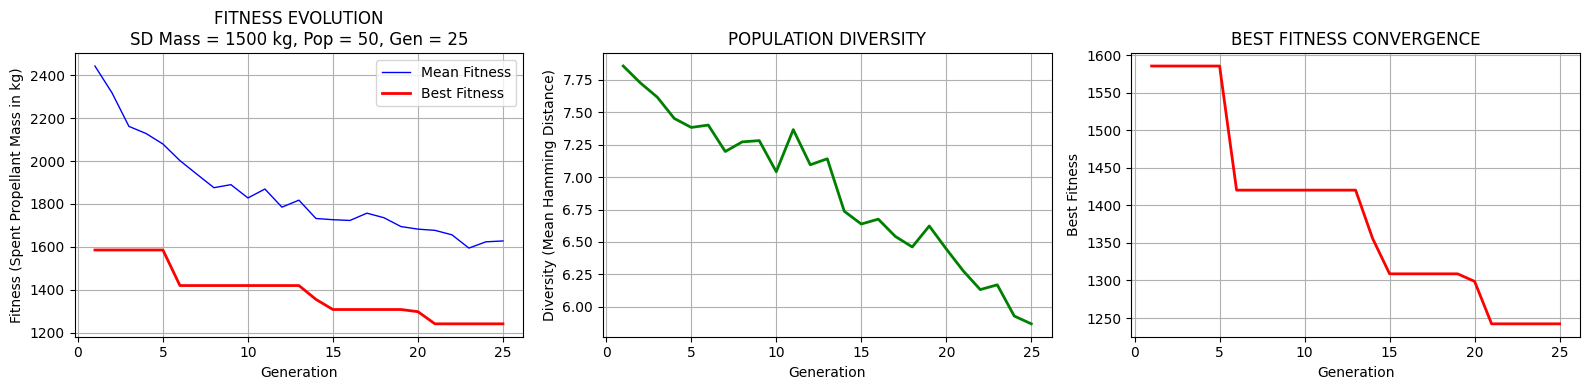

In [12]:
# Plot GA results - Fitness Evolution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Fitness over generations
axes[0].plot(range(1, ga_max_gen + 1), ga_mean, 'b-', label='Mean Fitness', linewidth=1)
axes[0].plot(range(1, ga_max_gen + 1), ga_best, 'r-', label='Best Fitness', linewidth=2)
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Fitness (Spent Propellant Mass in kg)')
axes[0].set_title(f'FITNESS EVOLUTION\nSD Mass = {sd_mass_ga} kg, Pop = {ga_popu_size}, Gen = {ga_max_gen}')
axes[0].legend()
axes[0].grid(True)

# Diversity over generations
axes[1].plot(range(1, ga_max_gen + 1), ga_diversity, 'g-', linewidth=2)
axes[1].set_xlabel('Generation')
axes[1].set_ylabel('Diversity (Mean Hamming Distance)')
axes[1].set_title('POPULATION DIVERSITY')
axes[1].grid(True)

# Best fitness convergence (zoomed)
axes[2].plot(range(1, ga_max_gen + 1), ga_best, 'r-', linewidth=2)
axes[2].set_xlabel('Generation')
axes[2].set_ylabel('Best Fitness')
axes[2].set_title('BEST FITNESS CONVERGENCE')
axes[2].grid(True)

plt.tight_layout()
plt.show()

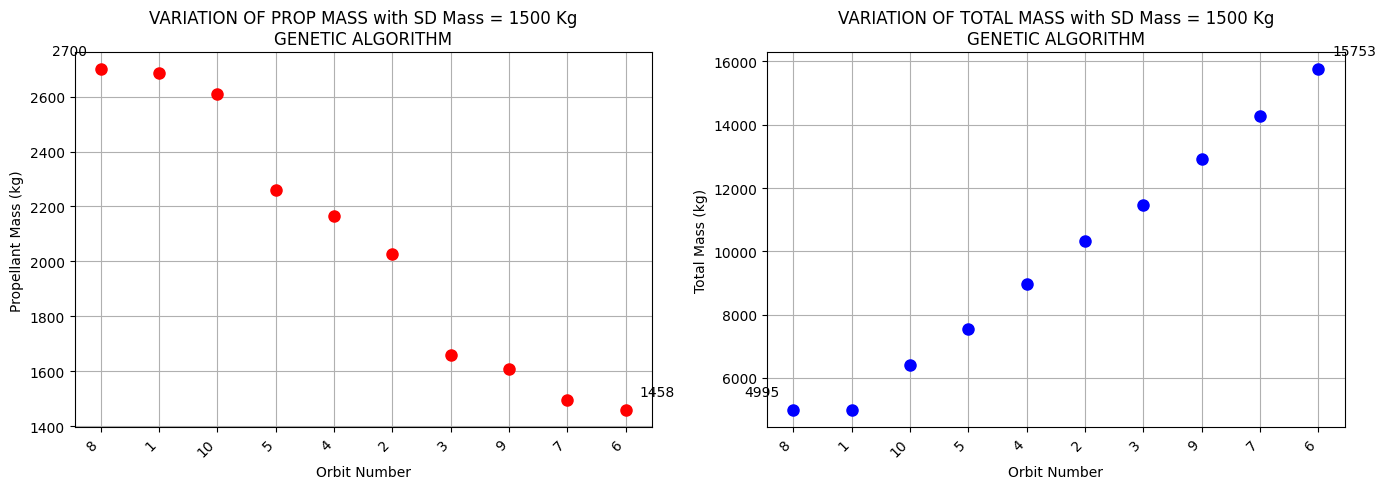

In [13]:
# Plot GA results - Mass changes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Propellant mass plot
axes[0].plot(range(1, n_ga + 1), ga_prop, 'or', markersize=8)
axes[0].set_xticks(range(1, n_ga + 1))
axes[0].set_xticklabels(ga_order, rotation=45, ha='right')
axes[0].set_xlabel('Orbit Number')
axes[0].set_ylabel('Propellant Mass (kg)')
axes[0].set_title(f'VARIATION OF PROP MASS with SD Mass = {sd_mass_ga} Kg\nGENETIC ALGORITHM')
axes[0].grid(True)
axes[0].annotate(f'{ga_prop[0]:.0f}', (1, ga_prop[0]), 
                textcoords="offset points", xytext=(-10, 10), ha='right')
axes[0].annotate(f'{ga_prop[-1]:.0f}', (n_ga, ga_prop[-1]), 
                textcoords="offset points", xytext=(10, 10), ha='left')

# Total mass plot
axes[1].plot(range(1, n_ga + 1), ga_total, 'ob', markersize=8)
axes[1].set_xticks(range(1, n_ga + 1))
axes[1].set_xticklabels(ga_order, rotation=45, ha='right')
axes[1].set_xlabel('Orbit Number')
axes[1].set_ylabel('Total Mass (kg)')
axes[1].set_title(f'VARIATION OF TOTAL MASS with SD Mass = {sd_mass_ga} Kg\nGENETIC ALGORITHM')
axes[1].grid(True)
axes[1].annotate(f'{ga_total[0]:.0f}', (1, ga_total[0]), 
                textcoords="offset points", xytext=(-10, 10), ha='right')
axes[1].annotate(f'{ga_total[-1]:.0f}', (n_ga, ga_total[-1]), 
                textcoords="offset points", xytext=(10, 10), ha='left')

plt.tight_layout()
plt.show()

---
# Summary

This notebook demonstrated three optimization methods for space debris removal mission planning:

| Method | Pros | Cons | Best For |
|--------|------|------|----------|
| **Brute Force** | Guarantees optimal solution | O(n!) complexity | Small problems (n ≤ 10) |
| **Series (Greedy)** | Fast, simple | May miss global optimum | Quick baseline solutions |
| **Genetic Algorithm** | Handles large problems, good solutions | Requires tuning | Large-scale optimization |

The GA implementation includes advanced features:
- Adaptive mutation switching based on stagnation detection
- Diversity preservation through population monitoring
- Repair function for maintaining feasibility

In [14]:
print("\n" + "="*60)
print("COMPARISON SUMMARY")
print("="*60)
print(f"\nBrute Force (5 orbits, SD=0kg): {bf_min_stp:.2f} kg spent")
print(f"Series Method (21 orbits, SD=1500kg): Visited {len(series_seq)}/21 orbits")
print(f"Genetic Algorithm (10 orbits, SD=1500kg): {ga_stp:.2f} kg spent")
print("\nNote: Different methods used different parameters for demonstration.")
print("\nFor production use with GA, increase population to 500 and generations to 250.")


COMPARISON SUMMARY

Brute Force (5 orbits, SD=0kg): 286.27 kg spent
Series Method (21 orbits, SD=1500kg): Visited 19/21 orbits
Genetic Algorithm (10 orbits, SD=1500kg): 1242.24 kg spent

Note: Different methods used different parameters for demonstration.

For production use with GA, increase population to 500 and generations to 250.
